In [14]:
print("Importing dependencies... ")

import sys, time
import os, os.path
sys.path.insert(0, "..")

# third party
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

# internal
import abstraction
import algorithm
from astropy.io import fits
from utility import IndexSchema, get_fits_paths, load_image_data
from examples.fits_to_mp4 import fits_to_mp4, data_to_mp4
from reference_method import ExternalRefs, RollingWindow

# ----

files_dir = os.path.abspath(os.path.join(".", "media", "large", "comparison"))

off_a = get_fits_paths(os.path.join(files_dir, "test_a", "off"))
off_a.sort()
off_b = get_fits_paths(os.path.join(files_dir, "test_b", "off"))
off_b.sort()

dest_a = get_fits_paths(os.path.join(files_dir, "test_a", "destretched"))
dest_a.sort()
dest_b = get_fits_paths(os.path.join(files_dir, "test_b", "destretched"))
dest_b.sort()

outpath_off = os.path.join(files_dir, "diff", "off")
outpath_dest = os.path.join(files_dir, "diff", "destretched")

os.makedirs(outpath_off, exist_ok=True)
os.makedirs(outpath_dest, exist_ok=True)

print(f"{len(off_a), len(off_b)} off files found")
print(f"{len(dest_a), len(dest_b)} destretched files found")


Importing dependencies... 
(1400, 1400) off files found
(1400, 1400) destretched files found


In [6]:
# write offset differences
for i, (file_a, file_b) in enumerate(zip(off_a, off_b)):
    data_a: np.ndarray = fits.open(file_a)[0].data
    data_b: np.ndarray = fits.open(file_b)[0].data
    diff = data_b - data_a

    fits.writeto(os.path.join(outpath_off, f"file_{i:0{6}d}.fits"), diff, overwrite=True)

# write destretched differences
for i, (file_a, file_b) in enumerate(zip(dest_a, dest_b)):
    data_a: np.ndarray = fits.open(file_a)[0].data
    data_b: np.ndarray = fits.open(file_b)[0].data
    diff = data_b - data_a

    fits.writeto(os.path.join(outpath_dest, f"file_{i:0{6}d}.fits"), diff, overwrite=True)


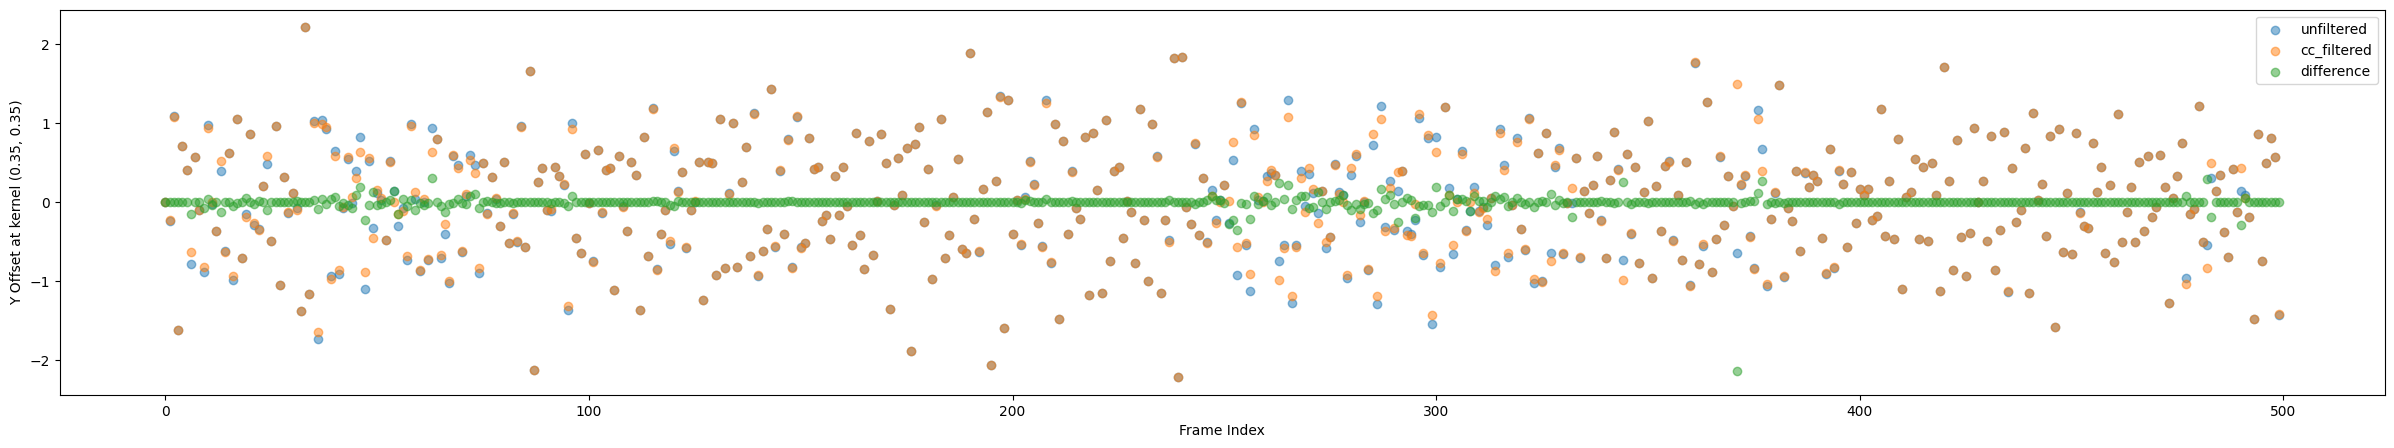

In [36]:
import matplotlib.pyplot as plt

# offset graph
ab = np.zeros((3, len(off_a)))
x_norm = 0.35
y_norm = 0.35
for i, (file_a, file_b) in enumerate(zip(off_a, off_b)):
    data_a: np.ndarray = fits.open(file_a)[0].data
    data_b: np.ndarray = fits.open(file_b)[0].data
    diff = data_b - data_a
    ab[0, i] = data_a[0, int(y_norm * data_a.shape[1]), int(x_norm * data_a.shape[2])]
    ab[1, i] = data_b[0, int(y_norm * data_b.shape[1]), int(x_norm * data_b.shape[2])]
    ab[2, i] = diff[0, int(y_norm * diff.shape[1]), int(x_norm * diff.shape[2])]

plt.figure(figsize=(30, 5))

ab = ab[:,0:500]

plt.scatter(range(0, len(ab[0])), ab[1], alpha=0.5, label="unfiltered")
plt.scatter(range(0, len(ab[0])), ab[0], alpha=0.5, label="cc_filtered")
plt.scatter(range(0, len(ab[0])), ab[2], alpha=0.5, label="difference")

plt.xlabel("Frame Index")
plt.ylabel(f"Y Offset at kernel {x_norm, y_norm}")
plt.legend()
plt.show()

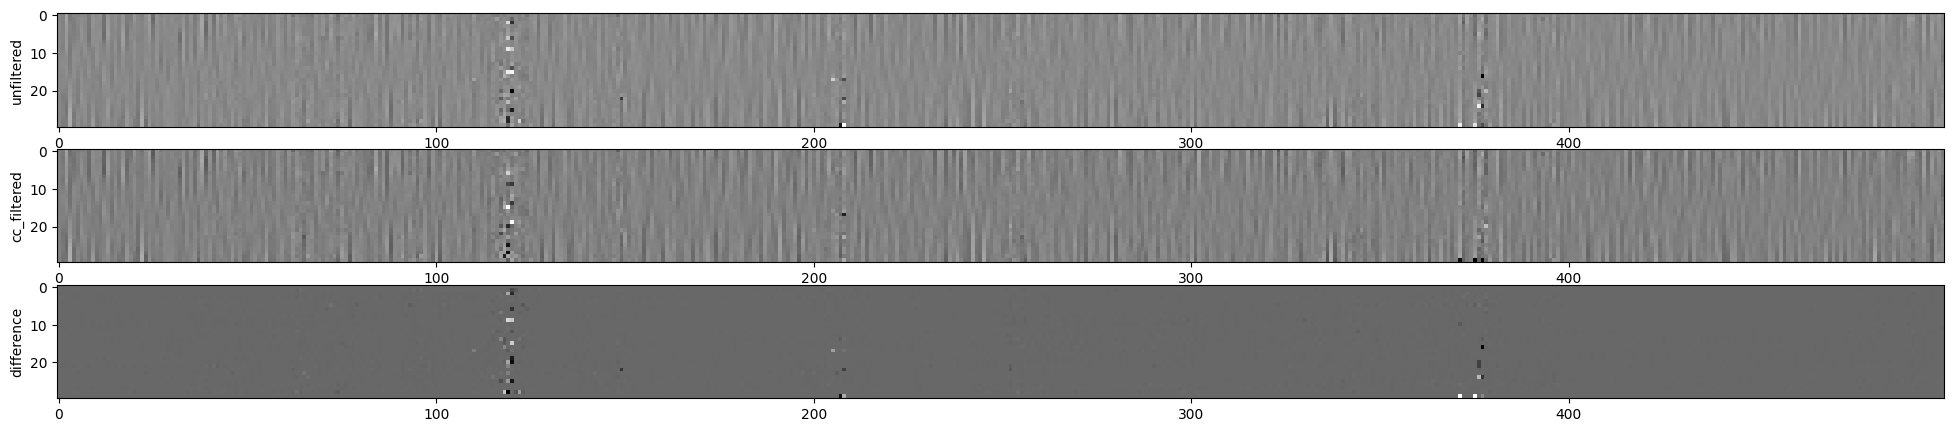

In [45]:
import matplotlib.pyplot as plt

# offset graph
data_a: np.ndarray = fits.open(off_a[0])[0].data
ab_slice = np.zeros((3, data_a.shape[1], len(off_a)))
x_norm = 0.35
for i, (file_a, file_b) in enumerate(zip(off_a, off_b)):
    data_a: np.ndarray = fits.open(file_a)[0].data
    data_b: np.ndarray = fits.open(file_b)[0].data
    diff = data_b - data_a
    ab_slice[0, :, i] = data_a[0, :, int(x_norm * data_a.shape[2])]
    ab_slice[1, :, i] = data_b[0, :, int(x_norm * data_b.shape[2])]
    ab_slice[2, :, i] = diff[0, :, int(x_norm * diff.shape[2])]

ab_slice = ab_slice[:, :,0:500]
plt.figure(figsize=(30, 5))

plt.subplot(3,1,1)
plt.imshow(ab_slice[1], interpolation="nearest", cmap="gray")
plt.ylabel("unfiltered")

plt.subplot(3,1,2)
plt.imshow(ab_slice[0], interpolation="nearest", cmap="gray")
plt.ylabel("cc_filtered")

plt.subplot(3,1,3)
plt.imshow(ab_slice[2], interpolation="nearest", cmap="gray")
plt.ylabel("difference")

plt.show()

In [8]:
import cv2

# load datasets (paths only to avoid large memory usage)
diff_paths = get_fits_paths(outpath_dest)
diff_paths.sort()

if len(dest_a) != len(dest_b) or len(dest_a) != len(diff_paths):
    print(len(dest_a), len(dest_b), len(diff_paths))
    raise Exception("Frame counts do not match for A/B/Diff")

# output video settings
first_frame = fits.open(dest_a[0])[0].data
height, width = first_frame.shape
out_path = os.path.join(files_dir, "diff", "destretched_compare.mp4")
fps = 60

writer = cv2.VideoWriter(
    out_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width * 2, height * 2),
    True,
)

for i in range(len(dest_a)):
    a = fits.open(dest_a[i])[0].data.astype(np.float32)
    b = fits.open(dest_b[i])[0].data.astype(np.float32)
    d = fits.open(diff_paths[i])[0].data.astype(np.float32)

    # per-frame normalization (A/B share scaling, diff separate)
    ab_min = min(np.min(a), np.min(b))
    ab_max = max(np.max(a), np.max(b))

    diff_min = np.min(d)
    diff_max = np.max(d)

    a_norm = np.clip((a - ab_min) / (ab_max - ab_min + 1e-9), 0, 1)
    b_norm = np.clip((b - ab_min) / (ab_max - ab_min + 1e-9), 0, 1)
    d_norm = np.clip((d - diff_min) / (diff_max - diff_min + 1e-9), 0, 1)

    a_u8 = (a_norm * 255).astype(np.uint8)
    b_u8 = (b_norm * 255).astype(np.uint8)
    d_u8 = (d_norm * 255).astype(np.uint8)

    # make 3-channel grayscale
    a_rgb = cv2.cvtColor(a_u8, cv2.COLOR_GRAY2BGR)
    b_rgb = cv2.cvtColor(b_u8, cv2.COLOR_GRAY2BGR)
    d_rgb = cv2.cvtColor(d_u8, cv2.COLOR_GRAY2BGR)

    # top row: A | B
    top = np.concatenate([b_rgb, a_rgb], axis=1)
    # bottom row: Diff | black padding
    pad = np.zeros_like(d_rgb)
    bottom = np.concatenate([d_rgb, pad], axis=1)

    frame = np.concatenate([top, bottom], axis=0)
    writer.write(frame)

writer.release()
print(f"Wrote {out_path}")


Wrote /home/tteck/Documents/development/flct_destretch/flctdestretch/examples/media/large/comparison/diff/destretched_compare.mp4
